# Addressed random distributions

Create the ordinary project environment with `./create_environment.sh`, run `conda activate tensor_dslab`, and then launch this notebook. The notebook never creates or changes an environment and is CPU-only.

This example follows a delayed-crosstalk frontier through TensorCore's public addressed APIs. The private TensorDSLab role key is imported only to keep the example faithful to package execution; it is an unsupported implementation detail and users do not configure production role keys.

In [1]:
import torch
import matplotlib.pyplot as plt
from tensor_core import PoissonDistribution, RngAddress, RngElements, Threefry4x32
from tensor_dslab.readout.runtime.keys import DELAYED_CROSSTALK_RNG_KEY

The parent counts are a small one-dimensional frontier. Two literal positive offsets carry expected offspring intensities. The deterministic retained-rate construction implements Poisson splitting/superposition directly at destinations; it is not a source-total Poisson followed by a Multinomial allocation.

In [2]:
parent_counts = torch.tensor([3, 2, 4, 1, 2, 1], dtype=torch.int64)
offsets = (1, 2)
kernel = torch.tensor([0.20, 0.10], dtype=torch.float64)
parent_counts

tensor([3, 2, 4, 1, 2, 1])

In [3]:
expected_rate = torch.zeros_like(parent_counts, dtype=torch.float64)
for offset, intensity in zip(offsets, kernel):
    expected_rate[offset:] += parent_counts[:-offset].to(torch.float64) * intensity
expected_rate

tensor([0.0000, 0.6000, 0.7000, 1.0000, 0.6000, 0.5000], dtype=torch.float64)

`RngElements` names the destination cells. `RngAddress` adds the package key and one generation coordinate. The root capacity remains attached to slices, so chunking never renumbers a destination.

In [4]:
elements = RngElements.from_shape(tuple(parent_counts.shape), device="cpu")
address = RngAddress.root(key=DELAYED_CROSSTALK_RNG_KEY, elements=elements, shape=(1,), quantum=0).select(0)
rng = Threefry4x32(seed=17)
raw_words = rng.words(address=address, ordinals=(0, 1, 2))
raw_words

tensor([[ 590579882, 3415149347, 1156002133],
        [1517655358,   92278503,  437712142],
        [3183584466, 3787345446,   14709620],
        [ 605950798, 1459734598,  849282475],
        [2488263767, 3574986711, 2207410930],
        [2707193893, 3994422719, 1864554088]])

In [5]:
global_before = torch.random.get_rng_state().clone()
sampled_avalanches = PoissonDistribution(mean=expected_rate).draw(rng=rng, address=address)
repeated_avalanches = PoissonDistribution(mean=expected_rate).draw(rng=Threefry4x32(seed=17), address=address)
assert torch.equal(sampled_avalanches, repeated_avalanches)
assert torch.equal(torch.random.get_rng_state(), global_before)
sampled_avalanches

tensor([0, 0, 1, 0, 1, 1])

In [6]:
chunks = []
for start, stop in ((0, 2), (2, 6)):
    chunk_elements = elements.slice(0, start, stop)
    chunk_address = RngAddress.root(key=DELAYED_CROSSTALK_RNG_KEY, elements=chunk_elements, shape=(1,), quantum=0).select(0)
    chunks.append(PoissonDistribution(mean=expected_rate[start:stop]).draw(rng=Threefry4x32(seed=17), address=chunk_address))
chunked_avalanches = torch.cat(chunks)
assert torch.equal(sampled_avalanches, chunked_avalanches)
chunked_avalanches

tensor([0, 0, 1, 0, 1, 1])

The panels separate the parent frontier, literal kernel, deterministic expected destination rate, and one addressed Poisson realization. This is an explanatory CPU example, not a calibration or performance claim.

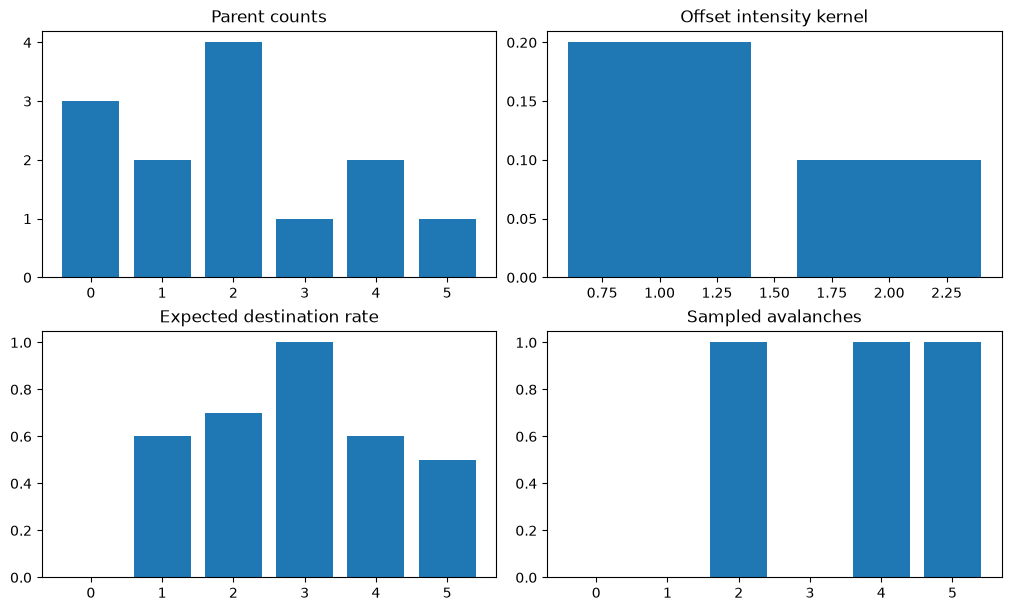

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
axes[0, 0].bar(range(parent_counts.numel()), parent_counts.to(device="cpu").tolist()); axes[0, 0].set_title("Parent counts")
axes[0, 1].bar(offsets, kernel.to(device="cpu").tolist()); axes[0, 1].set_title("Offset intensity kernel")
axes[1, 0].bar(range(expected_rate.numel()), expected_rate.to(device="cpu").tolist()); axes[1, 0].set_title("Expected destination rate")
axes[1, 1].bar(range(sampled_avalanches.numel()), sampled_avalanches.to(device="cpu").tolist()); axes[1, 1].set_title("Sampled avalanches")
plt.show()